In [31]:
import sys

import numpy as np
import matplotlib.pyplot as plt

# The editable install means we can import this anywhere, no sys.path hacks needed.
import cosmo_sim_tools as cosmosim

# NOTE: importing the top-level package does NOT pull in the subpackages,
# so we import the helpers explicitly:
from cosmo_sim_tools.arepo_tools import arepo_package
from cosmo_sim_tools import illustris as il
from cosmo_sim_tools import brahma

# Shared figure styling (fonts, ticks, legend) lives in py_files/plot_style.py
sys.path.append('../py_files/')
import plot_style as ps


In [32]:

Brahma_sim_path = '/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/'
Brahma_sim_name = 'SM5_DFD_3_TNG/'
Brahma_sim_file = Brahma_sim_path+Brahma_sim_name

In [33]:
# Which snapshots exist, and what redshift does each correspond to?
snapshots, redshifts = arepo_package.get_snapshot_redshift_correspondence(Brahma_sim_file)

# grab a valid snapshot number
snap0 = snapshots[0]

# read everything straight from the BRAHMA group-catalog header
header  = brahma.groupcat.loadHeader(Brahma_sim_file, snap0)
om0     = header['Omega0']
oml     = header['OmegaLambda']
h       = header['HubbleParam']
boxsize = header['BoxSize']

In [34]:
def final_med_nbh_vs_stellar_at_redshift(redshift, min_per_bin=15, max_bins=30):
    """Return adaptive-bin BH-count statistics versus stellar mass.

    The requested redshift is matched to the nearest available simulation
    snapshot. Equal-count bins are used in stellar mass, while statistics are
    calculated in linear BH counts for plotting on a logarithmic y-axis.
    """
    redshift_values = np.asarray(redshifts, dtype=float)
    snapshot_values = np.asarray(snapshots, dtype=int)
    snapshot_position = np.argmin(np.abs(redshift_values - redshift))
    snapshot = int(snapshot_values[snapshot_position])
    matched_redshift = float(redshift_values[snapshot_position])

    stellar_mass = brahma.groupcat.loadSubhalos(
        Brahma_sim_file, snapshot, fields='SubhaloMassType'
    )[:, 4]
    black_hole_count = brahma.groupcat.loadSubhalos(
        Brahma_sim_file, snapshot, fields='SubhaloLenType'
    )[:, 5]

    valid = (stellar_mass > 0) & (black_hole_count > 0)
    log_stellar_mass = np.log10(stellar_mass[valid]) + 10
    bh_counts = black_hole_count[valid].astype(float)

    if log_stellar_mass.size < min_per_bin:
        raise ValueError(
            f'Redshift {redshift:g} (snapshot {snapshot}) has only '
            f'{log_stellar_mass.size} valid subhalos; '
            f'min_per_bin={min_per_bin}.'
        )

    order = np.argsort(log_stellar_mass)
    sorted_mass = log_stellar_mass[order]
    sorted_counts = bh_counts[order]
    number_of_bins = min(max_bins, sorted_mass.size // min_per_bin)
    chunks = np.array_split(np.arange(sorted_mass.size), number_of_bins)

    bin_centers = np.array([np.mean(sorted_mass[chunk]) for chunk in chunks])
    medians = np.array([np.median(sorted_counts[chunk]) for chunk in chunks])
    fifths = np.array([
        np.percentile(sorted_counts[chunk], 5) for chunk in chunks
    ])
    ninety_fifths = np.array([
        np.percentile(sorted_counts[chunk], 95) for chunk in chunks
    ])

    return (
        bin_centers,
        medians,
        fifths,
        ninety_fifths,
        snapshot,
        matched_redshift,
    )

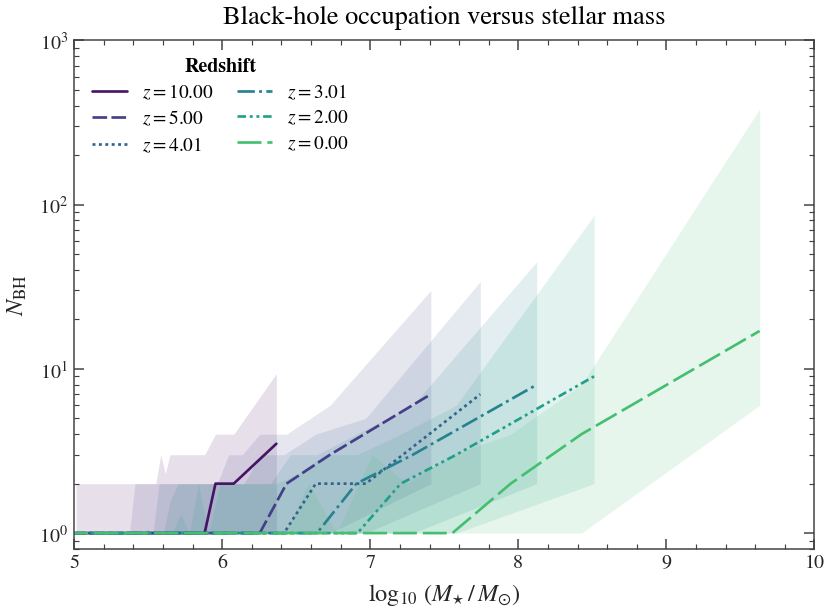

In [35]:
redshift_choices = [10, 5, 4, 3, 2, 0]

# One call sets fonts/ticks/legend for every figure from here on.
# Try e.g. ps.set_style('talk'), font_family='sans-serif', grid=True,
# or any rcParam by name: **{'axes.labelweight': 'bold'}
ps.set_style('paper', font_scale=1.15)

# Redshift is ordered, so a dark-to-light ramp reads better than the default
# categorical cycle; viridis is colorblind-safe (ps.sequential_colors also
# takes cmap='cividis' for the strictest CVD choice). The dash patterns
# repeat the same ordering, so the series stay separable without color.
line_colors = ps.sequential_colors(len(redshift_choices))
line_dashes = ps.line_styles(len(redshift_choices))

fig, ax = plt.subplots(figsize=(7.2, 5.4))
for line_color, line_dash, requested_redshift in zip(
    line_colors, line_dashes, redshift_choices
):
    (
        mass_bins,
        median_bh_counts,
        lower_bh_counts,
        upper_bh_counts,
        snapshot,
        matched_redshift,
    ) = final_med_nbh_vs_stellar_at_redshift(
        requested_redshift,
        min_per_bin=15,
        max_bins=30,
    )

    ax.plot(
        mass_bins,
        median_bh_counts,
        color=line_color,
        linestyle=line_dash,
        label=rf'$z = {matched_redshift:.2f}$',
    )
    ax.fill_between(
        mass_bins,
        lower_bh_counts,
        upper_bh_counts,
        color=line_color,
        alpha=0.13,
        linewidth=0,
    )

ax.set_xlim(5, 10)
ax.set_yscale('log', base=10)
ax.set_ylim(0.8, 1e3)
ax.set_xlabel(r'$\log_{10}\,(M_{\star}\,/\,M_{\odot})$')
ax.set_ylabel(r'$N_{\rm BH}$')
ax.set_title('Black-hole occupation versus stellar mass')
ax.legend(
    loc='upper left',
    ncols=2,
    title='Redshift',
    title_fontproperties={'weight': 'semibold'},
)
fig.tight_layout()
plt.show()


In [36]:
_occupation_cache = {}


def snapshot_closest_to_redshift(redshift):
    """Return the (snapshot, redshift) pair closest to the requested redshift."""
    redshift_values = np.asarray(redshifts, dtype=float)
    position = int(np.argmin(np.abs(redshift_values - redshift)))
    return int(np.asarray(snapshots, dtype=int)[position]), float(redshift_values[position])


def black_hole_subhalo_offsets(snapshot, sim_file=None):
    """Locate each subhalo's block of black holes in the group-ordered snapshot.

    Group-ordered particle files list BHs group by group, and within a group
    subhalo by subhalo (trailing 'fuzz' particles are bound to no subhalo).
    Subhalos are themselves stored in group order, so a subhalo's starting
    index is its group's offset plus the lengths of the preceding subhalos in
    that same group. Returns (offsets, lengths), both per subhalo.
    """
    sim_file = Brahma_sim_file if sim_file is None else sim_file
    subhalos = brahma.groupcat.loadSubhalos_postprocessed(
        sim_file, snapshot, fields=['SubhaloLenType', 'SubhaloGrNr']
    )
    groups = brahma.groupcat.loadHalos_postprocessed(
        sim_file, snapshot, fields=['GroupLenType', 'GroupFirstSub']
    )

    subhalo_bh_lengths = subhalos['SubhaloLenType'][:, 5].astype(np.int64)
    subhalo_group_number = subhalos['SubhaloGrNr'].astype(np.int64)
    group_bh_lengths = groups['GroupLenType'][:, 5].astype(np.int64)
    group_first_subhalo = groups['GroupFirstSub'].astype(np.int64)

    group_bh_offsets = np.concatenate(([0], np.cumsum(group_bh_lengths)))[:-1]
    running_subhalo_total = np.concatenate(([0], np.cumsum(subhalo_bh_lengths)))[:-1]

    subhalo_bh_offsets = (
        group_bh_offsets[subhalo_group_number]
        + running_subhalo_total
        - running_subhalo_total[group_first_subhalo[subhalo_group_number]]
    )
    return subhalo_bh_offsets, subhalo_bh_lengths


def count_central_and_wandering(snapshot, sim_file=None):
    """Split each subhalo's black holes into centrals and wanderers.

    A black hole is *central* when it sits inside the stellar half-mass radius
    of the subhalo it is bound to, and a *wanderer* otherwise. Distances use
    the periodic box, and both coordinates and radii are in ckpc/h, so no
    unit conversion is needed for the comparison.
    """
    sim_file = Brahma_sim_file if sim_file is None else sim_file
    subhalos = brahma.groupcat.loadSubhalos_postprocessed(
        sim_file,
        snapshot,
        fields=['SubhaloLenType', 'SubhaloMassType', 'SubhaloPos', 'SubhaloHalfmassRadType'],
    )
    subhalo_bh_offsets, subhalo_bh_lengths = black_hole_subhalo_offsets(snapshot, sim_file)

    stellar_half_mass_radius = subhalos['SubhaloHalfmassRadType'][:, 4]
    number_of_subhalos = subhalo_bh_lengths.size
    number_of_central = np.zeros(number_of_subhalos, dtype=np.int64)

    hosts = subhalo_bh_lengths > 0
    if np.any(hosts):
        bh_coordinates = np.atleast_2d(
            brahma.snapshot.loadSubset_groupordered(
                sim_file, snapshot, 5, fields=['Coordinates']
            )
        )
        starts = subhalo_bh_offsets[hosts]
        lengths = subhalo_bh_lengths[hosts]

        host_of_each_bh = np.repeat(np.flatnonzero(hosts), lengths)
        rank_within_host = (
            np.arange(int(lengths.sum())) - np.repeat(np.cumsum(lengths) - lengths, lengths)
        )
        row_of_each_bh = np.repeat(starts, lengths) + rank_within_host

        separation = bh_coordinates[row_of_each_bh] - subhalos['SubhaloPos'][host_of_each_bh]
        separation -= boxsize * np.round(separation / boxsize)
        distance_from_center = np.sqrt((separation ** 2).sum(axis=1))

        is_central = distance_from_center < stellar_half_mass_radius[host_of_each_bh]
        number_of_central = np.bincount(
            host_of_each_bh[is_central], minlength=number_of_subhalos
        )

    return {
        'stellar_mass': subhalos['SubhaloMassType'][:, 4] * 1e10 / h,
        'star_particle_count': subhalos['SubhaloLenType'][:, 4],
        'n_bh_total': subhalo_bh_lengths,
        'n_bh_central': number_of_central,
        'n_bh_wandering': subhalo_bh_lengths - number_of_central,
    }


def galaxy_occupation_table(redshift, min_star_particles=10):
    """Per-galaxy occupation flags at the snapshot nearest the given redshift.

    Galaxies are subhalos resolved by at least `min_star_particles` star
    particles. Below about five star particles SUBFIND reports a zero stellar
    half-mass radius, which would label every black hole a wanderer by
    construction, so that floor is a resolution requirement rather than a
    cosmetic cut. Every resolved galaxy enters the denominator, including the
    ones holding no black hole at all.
    """
    snapshot, matched_redshift = snapshot_closest_to_redshift(redshift)
    key = (snapshot, min_star_particles)
    if key in _occupation_cache:
        return _occupation_cache[key]

    counts = count_central_and_wandering(snapshot)
    galaxies = (counts['star_particle_count'] >= min_star_particles) & (counts['stellar_mass'] > 0)

    table = {
        'snapshot': snapshot,
        'matched_redshift': matched_redshift,
        'log_stellar_mass': np.log10(counts['stellar_mass'][galaxies]),
        'occupied_total': counts['n_bh_total'][galaxies] > 0,
        'occupied_central': counts['n_bh_central'][galaxies] > 0,
        'occupied_wandering': counts['n_bh_wandering'][galaxies] > 0,
    }
    _occupation_cache[key] = table
    return table


def occupation_fraction(log_stellar_mass, occupied, mass_grid, bandwidth=0.3, min_effective_count=8):
    """Smooth occupation fraction on `mass_grid`, as a Gaussian-weighted mean.

    Each galaxy contributes to a grid point with a Gaussian weight in
    log stellar mass, which traces the same fraction a histogram would give
    but without bin-edge steps. Grid points whose effective sample size
    (Kish) falls below `min_effective_count` are returned as NaN so the
    curves stop where the box runs out of galaxies instead of running on
    into noise.
    """
    weights = np.exp(-0.5 * ((log_stellar_mass[:, None] - mass_grid[None, :]) / bandwidth) ** 2)
    total_weight = weights.sum(axis=0)
    effective_count = total_weight ** 2 / np.maximum((weights ** 2).sum(axis=0), 1e-300)
    fraction = (weights * occupied[:, None]).sum(axis=0) / np.maximum(total_weight, 1e-300)
    return np.where(effective_count >= min_effective_count, fraction, np.nan)

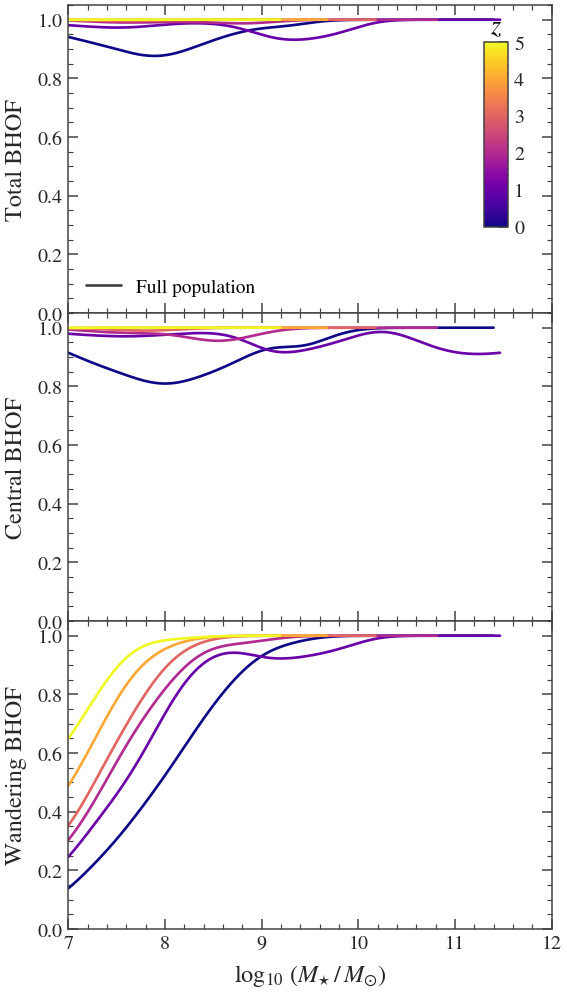

In [37]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ps.set_style('paper', font_scale=1.15)

redshift_choices = [0, 1, 2, 3, 4, 5]
mass_grid = np.linspace(7, 12, 300)

# Redshift is continuous here, so the curves are keyed to a colorbar rather
# than a legend; 'plasma' keeps z=0 dark and z=5 bright.
colormap = plt.get_cmap('plasma')
color_norm = Normalize(vmin=min(redshift_choices), vmax=max(redshift_choices))

panels = [
    ('occupied_total', 'Total BHOF'),
    ('occupied_central', 'Central BHOF'),
    ('occupied_wandering', 'Wandering BHOF'),
]

fig, axes = plt.subplots(3, 1, figsize=(5.2, 10), sharex=True)

for requested_redshift in redshift_choices:
    table = galaxy_occupation_table(requested_redshift)
    color = colormap(color_norm(table['matched_redshift']))
    for ax, (key, _) in zip(axes, panels):
        ax.plot(
            mass_grid,
            occupation_fraction(table['log_stellar_mass'], table[key], mass_grid),
            color=color,
        )

for ax, (_, label) in zip(axes, panels):
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

axes[-1].set_xlim(7, 12)
axes[-1].set_xlabel(r'$\log_{10}\,(M_{\star}\,/\,M_{\odot})$')

fig.subplots_adjust(hspace=0)

colorbar_axes = axes[0].inset_axes([0.86, 0.28, 0.05, 0.60])
colorbar = fig.colorbar(ScalarMappable(norm=color_norm, cmap=colormap), cax=colorbar_axes)
colorbar.set_ticks(redshift_choices)
colorbar.ax.set_title(r'$z$', pad=5)

axes[0].plot([], [], color='0.25', label='Full population')
axes[0].legend(loc='lower left', frameon=False)

plt.show()

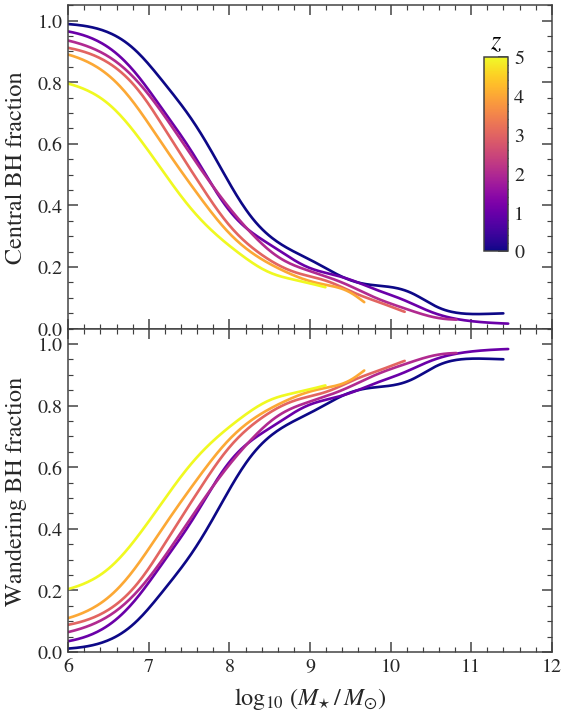

In [38]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

_bh_count_cache = {}


def galaxy_black_hole_counts(redshift, min_star_particles=5):
    """Per-galaxy black hole *counts* at the snapshot nearest a redshift.

    Same galaxy selection as `galaxy_occupation_table`, but keeping the counts
    rather than collapsing them to occupied/not-occupied flags.
    """
    snapshot, matched_redshift = snapshot_closest_to_redshift(redshift)
    key = (snapshot, min_star_particles)
    if key in _bh_count_cache:
        return _bh_count_cache[key]

    counts = count_central_and_wandering(snapshot)
    galaxies = (counts['star_particle_count'] >= min_star_particles) & (counts['stellar_mass'] > 0)

    table = {
        'snapshot': snapshot,
        'matched_redshift': matched_redshift,
        'log_stellar_mass': np.log10(counts['stellar_mass'][galaxies]),
        'n_bh_total': counts['n_bh_total'][galaxies].astype(float),
        'n_bh_central': counts['n_bh_central'][galaxies].astype(float),
        'n_bh_wandering': counts['n_bh_wandering'][galaxies].astype(float),
    }
    _bh_count_cache[key] = table
    return table


def black_hole_fraction(log_stellar_mass, selected_counts, total_counts, mass_grid,
                        bandwidth=0.3, min_effective_galaxies=8, max_single_galaxy_share=0.5):
    """Fraction of *black holes* that are of one kind, versus host stellar mass.

    Unlike the occupation fractions, which ask whether a galaxy holds at least
    one black hole of a kind, this pools black holes: every hole is weighted by
    its host's Gaussian weight in log stellar mass, so central and wandering
    fractions sum to one by construction.

    Pooling makes the estimate vulnerable to a single BH-rich galaxy, which can
    carry hundreds of holes and outvote every other galaxy in the window, so
    grid points are blanked where one galaxy supplies more than
    `max_single_galaxy_share` of the weight, or where fewer than
    `min_effective_galaxies` galaxies contribute at all.
    """
    weights = np.exp(-0.5 * ((log_stellar_mass[:, None] - mass_grid[None, :]) / bandwidth) ** 2)
    contribution = weights * total_counts[:, None]
    denominator = contribution.sum(axis=0)

    fraction = (weights * selected_counts[:, None]).sum(axis=0) / np.maximum(denominator, 1e-300)

    effective_galaxies = weights.sum(axis=0) ** 2 / np.maximum((weights ** 2).sum(axis=0), 1e-300)
    dominant_share = contribution.max(axis=0) / np.maximum(denominator, 1e-300)

    trustworthy = (
        (denominator > 0)
        & (effective_galaxies >= min_effective_galaxies)
        & (dominant_share <= max_single_galaxy_share)
    )
    return np.where(trustworthy, fraction, np.nan)


ps.set_style('paper', font_scale=1.15)

redshift_choices = [0, 1, 2, 3, 4, 5]
mass_grid = np.linspace(6, 12, 300)

colormap = plt.get_cmap('plasma')
color_norm = Normalize(vmin=min(redshift_choices), vmax=max(redshift_choices))

panels = [
    ('n_bh_central', 'Central BH fraction'),
    ('n_bh_wandering', 'Wandering BH fraction'),
]

fig, axes = plt.subplots(2, 1, figsize=(5.2, 7), sharex=True)

for requested_redshift in redshift_choices:
    table = galaxy_black_hole_counts(requested_redshift)
    color = colormap(color_norm(table['matched_redshift']))
    for ax, (key, _) in zip(axes, panels):
        ax.plot(
            mass_grid,
            black_hole_fraction(
                table['log_stellar_mass'], table[key], table['n_bh_total'], mass_grid
            ),
            color=color,
        )

for ax, (_, label) in zip(axes, panels):
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

axes[-1].set_xlim(6, 12)
axes[-1].set_xlabel(r'$\log_{10}\,(M_{\star}\,/\,M_{\odot})$')

fig.subplots_adjust(hspace=0)

colorbar_axes = axes[0].inset_axes([0.86, 0.24, 0.05, 0.60])
colorbar = fig.colorbar(ScalarMappable(norm=color_norm, cmap=colormap), cax=colorbar_axes)
colorbar.set_ticks(redshift_choices)
colorbar.ax.set_title(r'$z$', pad=5)

plt.show()

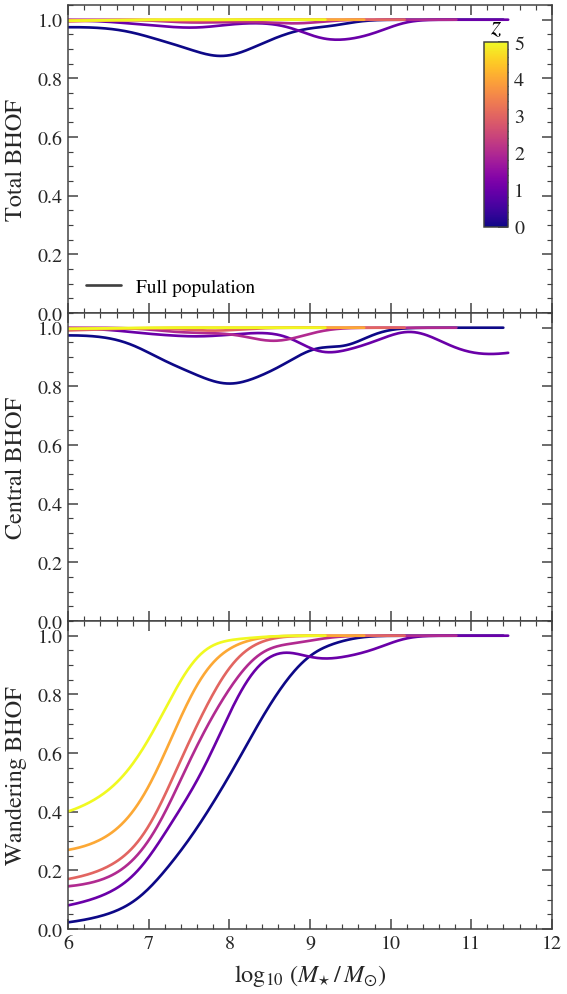

In [39]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

_population_cache = {}


def group_central_flag(snapshot, sim_file=None):
    """True for each subhalo that is the primary subhalo of its FoF group.

    'Central' is overloaded here: this is the *galaxy* sitting at the centre of
    its halo, as opposed to a satellite, and is unrelated to whether a black
    hole is central within its own galaxy.
    """
    sim_file = Brahma_sim_file if sim_file is None else sim_file
    subhalo_group_number = brahma.groupcat.loadSubhalos_postprocessed(
        sim_file, snapshot, fields='SubhaloGrNr'
    ).astype(np.int64)
    group_first_subhalo = brahma.groupcat.loadHalos_postprocessed(
        sim_file, snapshot, fields='GroupFirstSub'
    ).astype(np.int64)
    return group_first_subhalo[subhalo_group_number] == np.arange(subhalo_group_number.size)


def occupation_table_by_population(redshift, population='group centrals', min_star_particles=10):
    """Occupation flags for one galaxy population at the nearest snapshot.

    `population` selects 'group centrals' (primary subhalo of its FoF group),
    'satellites' (everything else), or 'all'. Satellites that have fallen deep
    into a massive host are stripped of their black holes, so splitting on this
    separates that environmental effect from the seeding history.
    """
    snapshot, matched_redshift = snapshot_closest_to_redshift(redshift)
    key = (snapshot, population, min_star_particles)
    if key in _population_cache:
        return _population_cache[key]

    counts = count_central_and_wandering(snapshot)
    resolved = (counts['star_particle_count'] >= min_star_particles) & (counts['stellar_mass'] > 0)

    is_group_central = group_central_flag(snapshot)
    if population == 'group centrals':
        selected = resolved & is_group_central
    elif population == 'satellites':
        selected = resolved & ~is_group_central
    elif population == 'all':
        selected = resolved
    else:
        raise ValueError(f"unknown population {population!r}")

    table = {
        'snapshot': snapshot,
        'matched_redshift': matched_redshift,
        'population': population,
        'log_stellar_mass': np.log10(counts['stellar_mass'][selected]),
        'occupied_total': counts['n_bh_total'][selected] > 0,
        'occupied_central': counts['n_bh_central'][selected] > 0,
        'occupied_wandering': counts['n_bh_wandering'][selected] > 0,
    }
    _population_cache[key] = table
    return table


ps.set_style('paper', font_scale=1.15)

population = 'all'
redshift_choices = [0, 1, 2, 3, 4, 5]
mass_grid = np.linspace(6, 12, 300)

colormap = plt.get_cmap('plasma')
color_norm = Normalize(vmin=min(redshift_choices), vmax=max(redshift_choices))

panels = [
    ('occupied_total', 'Total BHOF'),
    ('occupied_central', 'Central BHOF'),
    ('occupied_wandering', 'Wandering BHOF'),
]

fig, axes = plt.subplots(3, 1, figsize=(5.2, 10), sharex=True)

for requested_redshift in redshift_choices:
    table = occupation_table_by_population(requested_redshift, population=population)
    color = colormap(color_norm(table['matched_redshift']))
    for ax, (key, _) in zip(axes, panels):
        ax.plot(
            mass_grid,
            occupation_fraction(table['log_stellar_mass'], table[key], mass_grid),
            color=color,
        )

for ax, (_, label) in zip(axes, panels):
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

axes[-1].set_xlim(6, 12)
axes[-1].set_xlabel(r'$\log_{10}\,(M_{\star}\,/\,M_{\odot})$')

fig.subplots_adjust(hspace=0)

colorbar_axes = axes[0].inset_axes([0.86, 0.28, 0.05, 0.60])
colorbar = fig.colorbar(ScalarMappable(norm=color_norm, cmap=colormap), cax=colorbar_axes)
colorbar.set_ticks(redshift_choices)
colorbar.ax.set_title(r'$z$', pad=5)

population_label = {
    'all': 'Full population',
    'group centrals': 'Group centrals only',
    'satellites': 'Satellites only',
}[population]
axes[0].plot([], [], color='0.25', label=population_label)
axes[0].legend(loc='lower left', frameon=False)

plt.show()

## One interactive figure instead of three panels

The matplotlib panels above show 18 curves across 3 axes. Below is the same information as a single
plotly figure: a **redshift slider**, all three occupation fractions on screen together
(distinguished by colour *and* dash pattern), and buttons to switch the **galaxy population**
between all galaxies, group centrals and satellites.

### The one idea that makes this work

Plotly's sliders and buttons are **stateless**. Each control writes an *absolute* update to the
figure and cannot read what the other control currently has selected. So if two controls write the
same property, they clobber each other — move the slider and it undoes the button, press a button
and it throws away your redshift.

The fix is to keep each control on its **own property**:

| Control | Method | Property it writes |
|---|---|---|
| redshift slider | `restyle` | `y` — the curve data |
| population buttons | `restyle` | `visible` — which traces show |

### Why there are nine traces

This is the interesting part, and it changed when the buttons were switched from *quantity* to
*population*.

Redshift changes the curve data. Population **also** changes the curve data — group centrals and
satellites have genuinely different occupation fractions. So the naive implementation puts both
controls on `y`, and they collide.

The way out is not to make the buttons smarter, it is to **add traces**. Materialise all three
populations up front:

```
traces 0,1,2  = All galaxies   (Total, Central, Wandering)
traces 3,4,5  = Group centrals (Total, Central, Wandering)
traces 6,7,8  = Satellites     (Total, Central, Wandering)
```

Now the buttons only have to reveal one block of three, which is a `visible` update, and the slider
goes back to owning `y` alone. Nine traces buys back the orthogonality.

That is the general move worth remembering: **when a second selector would also need to write data,
pre-materialise its options as traces so it can write visibility instead.** It costs memory
(9 × 18 arrays here, trivial) and buys a control scheme that cannot fight itself.

Note what is *not* multiplied — the 18 redshifts stay as slider steps rather than becoming traces.
Materialising those too would mean 9 × 18 = 162 traces. You pre-materialise the axis that needs to
be visible simultaneously; you swap data along the axis that does not.

### The restyle signature

Every `restyle` update has the same two-part shape:

```python
args=[{'property': [value_for_trace0, value_for_trace1, ...]}, [0, 1, 2, ...]]
#      \_______ what to set, one entry per trace _______/      \_ which traces _/
```

The second element lists the trace indices to apply to; the list inside the dict is distributed
across them positionally. One slider step therefore pushes all nine curves in a single update.

Two sibling methods are worth knowing: `relayout` changes figure-wide things (axis ranges, titles)
and `update` does both at once. This figure only needs `restyle`.

### NaN becomes a gap, for free

`occupation_fraction` already returns `NaN` where the effective sample size drops below
`min_effective_count`. With `connectgaps=False` plotly breaks the line at each NaN, so curves stop
where the box runs out of galaxies — the same masking as the matplotlib version, no extra code.

### What to expect when you drag the slider

The high-redshift steps are legitimately short. At z = 10 the box holds only ~321 resolved galaxies
reaching log M\* ≈ 7.2; by z = 0 the curve extends to ≈ 11.6. The x-range is deliberately **fixed**
rather than autoscaled, so dragging the slider reads as the population growing to the right over
cosmic time instead of the axis jumping on every step.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------------------------
# 1. The two seed models. Both runs share an identical 33-snapshot redshift
#    grid, the same box and the same h, which is what lets a single slider
#    drive both panels honestly.
# ---------------------------------------------------------------------------
seed_models = [
    ('SM5_DFD_3_TNG', 'Heavy-Lenient'),
    ('SM5_LW10_DFD_3_TNG', 'Heavy-Restrictive'),
]
simulation_files = {name: Brahma_sim_path + name + '/' for name, _ in seed_models}

snapshot_values = np.asarray(snapshots, dtype=int)
redshift_values = np.asarray(redshifts, dtype=float)
slider_snapshots = np.arange(15, 33)
slider_redshifts = np.array(
    [redshift_values[np.flatnonzero(snapshot_values == s)[0]] for s in slider_snapshots]
)

mass_grid = np.linspace(6, 12, 300)

# Resolution cut. Five star particles is only the floor at which SUBFIND stops
# returning a zero stellar half-mass radius; ten is a defensible resolution
# standard and drops the most heavily stripped satellite remnants.
min_star_particles = 10

quantities = [
    ('n_bh_total', 'Total', '#1F3A93', 'solid'),
    ('n_bh_central', 'Central', '#D9480F', 'dash'),
    ('n_bh_wandering', 'Wandering', '#2B8A3E', 'dashdot'),
]
populations = ['All galaxies', 'Group centrals', 'Satellites']

# ---------------------------------------------------------------------------
# 2. Precompute: 2 runs x 3 populations x 3 quantities x 18 redshifts.
#    One snapshot read per (run, snapshot) serves all three populations.
# ---------------------------------------------------------------------------
# Survives re-running this cell, so a second run is instant. The cached value is
# the finished curves (a few hundred KB), not the per-subhalo arrays behind them.
if '_seed_curve_cache' not in globals():
    _seed_curve_cache = {}


def snapshot_curves(model, snapshot):
    """Occupation curves for one run and snapshot, for all populations."""
    # min_star_particles belongs in the key: without it, changing the cut would
    # silently return curves computed under the old one.
    cache_key = (model, int(snapshot), min_star_particles,
                 tuple(mass_grid[[0, -1]]), mass_grid.size)
    if cache_key in _seed_curve_cache:
        return _seed_curve_cache[cache_key], True

    sim_file = simulation_files[model]
    counts = count_central_and_wandering(snapshot, sim_file)
    is_group_central = group_central_flag(snapshot, sim_file)
    resolved = ((counts['star_particle_count'] >= min_star_particles)
                & (counts['stellar_mass'] > 0))

    population_masks = {
        'All galaxies': resolved,
        'Group centrals': resolved & is_group_central,
        'Satellites': resolved & ~is_group_central,
    }
    result = {}
    for population, mask in population_masks.items():
        log_stellar_mass = np.log10(counts['stellar_mass'][mask])
        result[population] = {
            key: occupation_fraction(log_stellar_mass, counts[key][mask] > 0, mass_grid)
            for key, _, _, _ in quantities
        }
    _seed_curve_cache[cache_key] = result
    return result, False


curves = {
    model: {population: {key: [] for key, _, _, _ in quantities} for population in populations}
    for model, _ in seed_models
}

total_reads = len(seed_models) * len(slider_snapshots)
done = 0
for model, _ in seed_models:
    for snapshot in slider_snapshots:
        result, was_cached = snapshot_curves(model, snapshot)
        for population in populations:
            for key, _, _, _ in quantities:
                curves[model][population][key].append(result[population][key])
        done += 1
        print(f'  [{done:2d}/{total_reads}] {model:22s} snap {snapshot:2d}'
              f'{"  (cached)" if was_cached else ""}', flush=True)

initial_index = len(slider_redshifts) - 1   # opens at z = 0

# ---------------------------------------------------------------------------
# 3. Eighteen traces: 2 panels x 3 populations x 3 quantities.
#    The slider still owns `y` and the buttons still own `visible`, so the two
#    controls stay on disjoint properties -- adding a second panel just widens
#    the trace list, it does not change the scheme.
#    Only the left panel carries legend entries; the right panel repeats the
#    same three styles, so a second set would be noise.
# ---------------------------------------------------------------------------
trace_order = [
    (model, population, key)
    for population in populations
    for column, (model, _) in enumerate(seed_models)
    for key, _, _, _ in quantities
]
all_traces = list(range(len(trace_order)))

figure = make_subplots(
    rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.045,
    subplot_titles=[f'<b>{name}</b><br><span style="font-size:11.5px;color:#5A6070">{note}</span>'
                    for name, note in seed_models],
)

for population in populations:
    for column, (model, _) in enumerate(seed_models):
        for key, label, colour, dash in quantities:
            figure.add_trace(
                go.Scatter(
                    x=mass_grid,
                    y=curves[model][population][key][initial_index],
                    name=label,
                    mode='lines',
                    line=dict(color=colour, width=2.5, dash=dash),
                    connectgaps=False,
                    visible=(population == populations[0]),
                    showlegend=(column == 0),
                    legendgroup=label,
                    hovertemplate=f'<b>{label}</b>   %{{y:.3f}}<extra></extra>',
                ),
                row=1, col=column + 1,
            )

# ---------------------------------------------------------------------------
# 4. One slider, both panels: each step rewrites `y` on all eighteen traces.
# ---------------------------------------------------------------------------
slider_steps = [
    dict(
        method='restyle',
        args=[{'y': [curves[model][population][key][index]
                     for model, population, key in trace_order]}, all_traces],
        label=f'{redshift:.2f}',
    )
    for index, redshift in enumerate(slider_redshifts)
]

# ---------------------------------------------------------------------------
# 5. Buttons reveal one population across both panels (six traces at a time).
# ---------------------------------------------------------------------------
population_buttons = [
    dict(
        method='restyle',
        args=[{'visible': [trace_population == population
                           for _, trace_population, _ in trace_order]}, all_traces],
        label=population,
    )
    for population in populations
]

# ---------------------------------------------------------------------------
# 6. Layout.
# ---------------------------------------------------------------------------
axis_style = dict(
    showline=True, linewidth=1.3, linecolor='#333333', mirror=True,
    ticks='outside', ticklen=7, tickwidth=1.1, tickcolor='#333333',
    showgrid=True, gridcolor='rgba(0,0,0,0.07)', gridwidth=1, zeroline=False,
)
minor_style = dict(ticks='outside', ticklen=4, tickwidth=0.8, showgrid=False)

figure.update_xaxes(
    title='log<sub>10</sub> (M<sub>&#9733;</sub> / M<sub>&#9737;</sub>)',
    range=[6, 12], dtick=1, minor=dict(dtick=0.25, **minor_style), **axis_style,
)
figure.update_yaxes(range=[0, 1.05], dtick=0.2, minor=dict(dtick=0.05, **minor_style), **axis_style)
figure.update_yaxes(title='occupation fraction', row=1, col=1)

# make_subplots parks its titles just above each panel, which is exactly where the
# buttons and legend want to be. Pin them to their own band low down instead.
for annotation in figure.layout.annotations:
    annotation.update(
        y=1.01, yanchor='bottom',
        font=dict(size=13.5, family='Georgia, "Times New Roman", serif'),
    )

figure.update_layout(
    template='simple_white',
    width=1080, height=680,
    font=dict(family='Georgia, "Times New Roman", serif', size=13.5, color='#1A1A1A'),
    plot_bgcolor='white', paper_bgcolor='white',
    title=dict(
        text=('<b>Black hole occupation fraction: two seed models</b>'
              '<br><span style="font-size:12.5px;color:#5A6070">'
              'BRAHMA &#183; L12p5n512 &#183; Heavy-Lenient vs Heavy-Restrictive</span>'),
        x=0.008, xanchor='left', y=0.975, yanchor='top', font=dict(size=19),
    ),
    hovermode='x unified',
    legend=dict(
        orientation='v', x=0.452, xanchor='right', y=0.045, yanchor='bottom',
        bgcolor='rgba(255,255,255,0.88)', bordercolor='#D8DCE3', borderwidth=1,
        font=dict(size=12), itemwidth=30,
    ),
    updatemenus=[dict(
        type='buttons', direction='right', buttons=population_buttons,
        x=0, xanchor='left', y=1.28, yanchor='top', showactive=True,
        bgcolor='#F4F4F4', bordercolor='#B8B8B8', borderwidth=1,
        font=dict(size=12), pad=dict(l=6, r=6, t=5, b=5),
    )],
    sliders=[dict(
        active=initial_index, steps=slider_steps,
        currentvalue=dict(prefix='z = ', font=dict(size=16), xanchor='left', offset=12),
        pad=dict(t=65, l=4, r=4), len=0.95, x=0.025,
        bgcolor='#E4E4E4', activebgcolor='#1F3A93', bordercolor='#B8B8B8',
        tickcolor='#666666', font=dict(size=11),
    )],
    margin=dict(l=80, r=35, t=185, b=95),
)

# Save the figure for the GitHub Pages build. Then, from the repo root:
#     python py_files/build_docs.py
# which splices it into the marked block in docs/index.html. Saving JSON rather
# than HTML means rebuilding the page never has to re-read /orange.
figure.write_json('../figures/bhof_occupation.json')

figure.show()